# Multilayer Perceptron (MLP) from Scratch with NumPy

## Introduction

A **logistic regression** model can only learn a *linear* decision boundary — it partitions the feature space with a single hyperplane. Many real classification problems are **not linearly separable**.

The classic example is the **XOR problem**:

| $x_1$ | $x_2$ | $y = \mathbb{1}[x_1 x_2 > 0]$ |
|--------|--------|-------------------------------|
| + | + | 1 |
| + | − | 0 |
| − | + | 0 |
| − | − | 1 |

No single straight line can separate the 1s from the 0s. A **multilayer perceptron** solves this by composing multiple linear transformations with non-linear activations, giving the network the ability to carve out non-linear decision regions.

## Statistical Model

A 2-layer MLP with sigmoid activations computes:

$$\hat{y} = \sigma\!\left(\sigma(X W_1 + b_1)\, W_2 + b_2\right)$$

## Notation

| Symbol | Meaning |
|--------|---------|
| $m$ | Number of training samples |
| $n_{\text{input}}$ | Number of input features (2 here) |
| $n_{\text{hidden}}$ | Number of neurons in the hidden layer |
| $n_{\text{output}}$ | Number of output neurons (1 for binary classification) |
| $W_1 \in \mathbb{R}^{n_{\text{input}} \times n_{\text{hidden}}}$ | Input→hidden weight matrix |
| $b_1 \in \mathbb{R}^{1 \times n_{\text{hidden}}}$ | Hidden layer bias |
| $W_2 \in \mathbb{R}^{n_{\text{hidden}} \times n_{\text{output}}}$ | Hidden→output weight matrix |
| $b_2 \in \mathbb{R}^{1 \times n_{\text{output}}}$ | Output layer bias |
| $Z_1, A_1$ | Pre- and post-activation of hidden layer |
| $Z_2, A_2$ | Pre- and post-activation of output layer |
| $\mathcal{L}$ | Binary cross-entropy loss |
| $\alpha$ | Learning rate |

## Roadmap

1. Generate an XOR-like dataset
2. Show that logistic regression fails
3. Build the MLP forward pass
4. Derive and implement backpropagation
5. Train with mini-batch gradient descent
6. Evaluate accuracy and visualise the decision boundary

In [ ]:
import numpy as np
np.random.seed(42)

## Dataset: The XOR Problem

We generate 1,000 samples $(x_1, x_2) \sim \mathcal{N}(0, I)$ and label them:

$$y = \mathbb{1}[x_1 \cdot x_2 > 0]$$

This creates a **non-linear** (checkerboard) decision boundary that no linear model can fit.

In [ ]:
# Create a simple dummy dataset
def create_dummy_data(n_samples=1000):
    X = np.random.randn(n_samples, 2)
    y = (X[:, 0] * X[:, 1] > 0).astype(int).reshape(-1, 1)
    return X, y

In [ ]:
X, y = create_dummy_data()
print("X:", X[:5])
print("y:", y[:5])
print("X shape:", X.shape)
print("y shape:", y.shape)

X: [[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]
 [-0.23415337 -0.23413696]
 [ 1.57921282  0.76743473]
 [-0.46947439  0.54256004]]
y: [[0]
 [1]
 [1]
 [1]
 [0]]
X shape: (1000, 2)
y shape: (1000, 1)


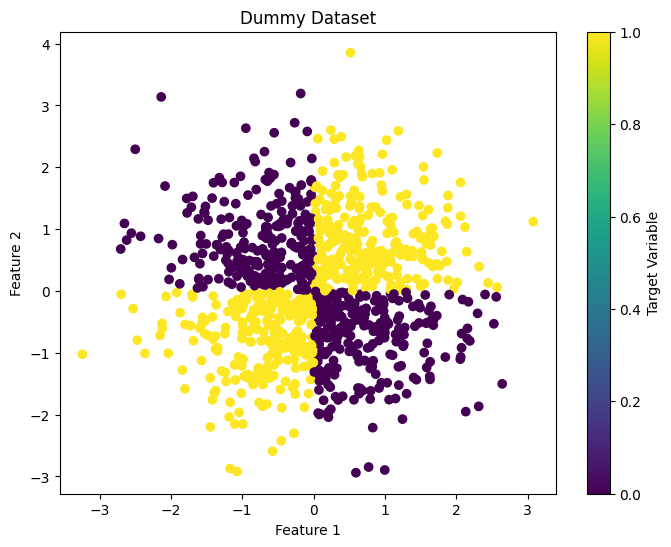

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dummy Dataset')
plt.colorbar(label='Target Variable')
plt.show()


## Why Logistic Regression Fails

Logistic regression learns a linear decision boundary $\boldsymbol{\theta}^\top \mathbf{x} = 0$. On the XOR dataset this boundary cannot separate the two classes — regardless of how many iterations we train for, accuracy plateaus near 50%.

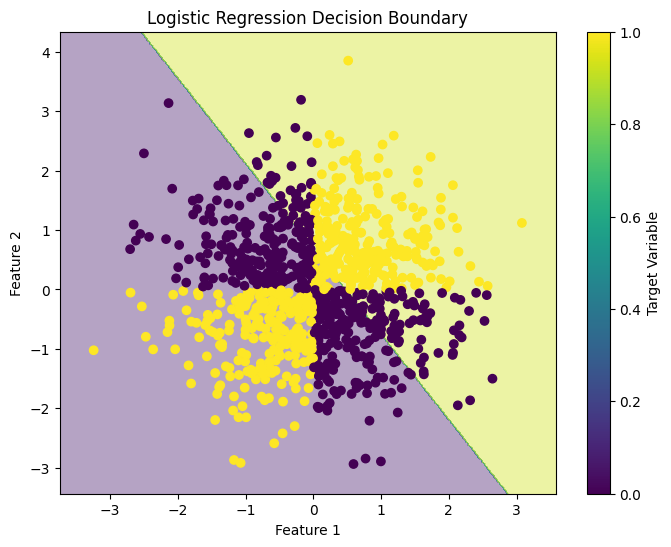

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create and fit a logistic regression model
model = LogisticRegression()
model.fit(X, y.flatten())

# Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.colorbar(label='Target Variable')
plt.show()


## From Linear to Non-linear: The Need for Depth

The logistic regression boundary (above) is a straight line that clearly fails to separate the quadrant-based labels. To model this pattern we need a function that can carve **curved, non-convex** regions.

**Universal approximation theorem (Cybenko, 1989):** A feedforward neural network with a single hidden layer containing a sufficient number of neurons can approximate any continuous function on a compact subset of $\mathbb{R}^n$ to arbitrary precision.

The key ingredient: stacking linear layers with *non-linear activations* allows the network to represent non-linear mappings.

# Neural Network Training with Backpropagation

### 1. Network Architecture
We are implementing a simple feedforward neural network with:
- An input layer of size $n_{\text{input}}$ (2 in this case).
- One hidden layer with $n_{\text{hidden}}$ neurons.
- An output layer of size $n_{\text{output}}$ (1 for binary classification).


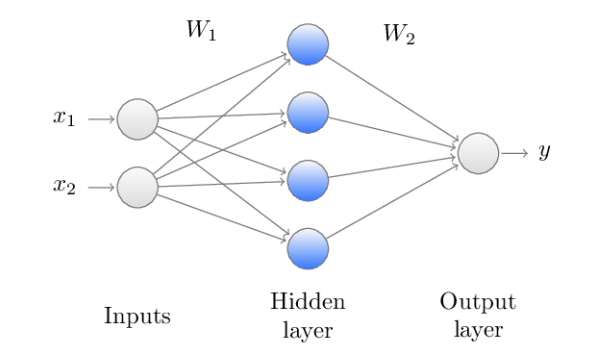

## Theory: Forward Propagation

Given an input batch $X \in \mathbb{R}^{m \times n_{\text{input}}}$:

**Hidden layer:**

$$Z_1 = X W_1 + b_1 \in \mathbb{R}^{m \times n_{\text{hidden}}}$$
$$A_1 = \sigma(Z_1) \quad \text{(element-wise sigmoid)}$$

**Output layer:**

$$Z_2 = A_1 W_2 + b_2 \in \mathbb{R}^{m \times 1}$$
$$A_2 = \sigma(Z_2) \quad \text{(predicted probability } \hat{y} \in (0,1)\text{)}$$

The sigmoid $\sigma(z) = \frac{1}{1+e^{-z}}$ squashes any real value into $(0,1)$, making it interpretable as a probability.

### 3. Loss Function

For binary classification, we use the **binary cross-entropy loss**:

$$
\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left( y_i \log(A_2^{(i)}) + (1 - y_i) \log(1 - A_2^{(i)}) \right)
$$

where:
- $y_i$ is the true label for the $i$-th sample.
- $A_2^{(i)}$ is the predicted probability for the $i$-th sample.

### 4. Backpropagation

Backpropagation computes the gradients of the loss function with respect to the network parameters to update them.

#### Step 1: Output Layer Gradients
1. **Loss Gradient with respect to $Z_2$**:
   $$
   \delta_2 = \frac{\partial \mathcal{L}}{\partial Z_2} = A_2 - y
   $$
   This is the error term for the output layer.

2. **Gradient with respect to $W_2$**:
   $$
   \frac{\partial \mathcal{L}}{\partial W_2} = A_1^T \delta_2
   $$

3. **Gradient with respect to $b_2$**:
   $$
   \frac{\partial \mathcal{L}}{\partial b_2} = \sum_{i=1}^{m} \delta_2
   $$

#### Step 2: Hidden Layer Gradients
1. **Error Term for Hidden Layer**:
   $$
   \delta_1 = \frac{\partial \mathcal{L}}{\partial Z_1} = \delta_2 W_2^T \cdot \sigma'(Z_1)
   $$
   where $ \sigma'(Z_1) = \sigma(Z_1) (1 - \sigma(Z_1)) $ is the derivative of the sigmoid function.

2. **Gradient with respect to $W_1$**:
   $$
   \frac{\partial \mathcal{L}}{\partial W_1} = X^T \delta_1
   $$

3. **Gradient with respect to $b_1$**:
   $$
   \frac{\partial \mathcal{L}}{\partial b_1} = \sum_{i=1}^{m} \delta_1
   $$


### 5. Parameter Update (Gradient Descent)

The parameters are updated using gradient descent:

$$
W_1 = W_1 - \alpha \frac{\partial \mathcal{L}}{\partial W_1}
$$
$$
b_1 = b_1 - \alpha \frac{\partial \mathcal{L}}{\partial b_1}
$$
$$
W_2 = W_2 - \alpha \frac{\partial \mathcal{L}}{\partial W_2}
$$
$$
b_2 = b_2 - \alpha \frac{\partial \mathcal{L}}{\partial b_2}
$$

where $ \alpha $ is the learning rate.

---

### Summary of Backpropagation Steps:
1. **Forward pass** to calculate $Z_1$, $A_1$, $Z_2$, $A_2$.
2. Compute the **loss** $ \mathcal{L} $.
3. **Backward pass** to compute gradients with respect to $W_2$, $b_2$, $W_1$, $b_1$.
4. **Update weights and biases** using the gradients.

This step-by-step process minimizes the loss, allowing the network to learn from the data.

## Implementation

### Sigmoid Function and Its Derivative

$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad \sigma'(z) = \sigma(z)\,(1-\sigma(z))$$

The derivative has a convenient self-referential form — useful because $\sigma(Z_1)$ is already computed during the forward pass.

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

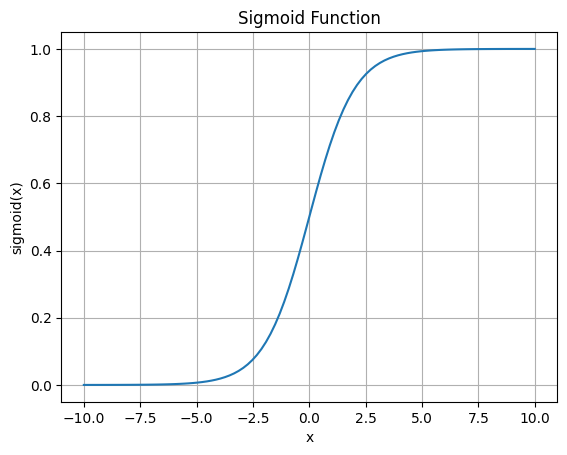

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x_plot = np.linspace(-10, 10, 100)

# Calculate sigmoid values
y_plot = sigmoid(x_plot)

# Plot the sigmoid function
plt.plot(x_plot, y_plot)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()


The derivative $\sigma'(z) = \sigma(z)(1-\sigma(z))$ is maximised at $z=0$ (value $0.25$) and approaches 0 at both extremes — the root of the **vanishing gradient** problem with deep sigmoid networks.

In [ ]:
def sigmoid_derivative(x):
  return sigmoid(x) * (1 - sigmoid(x))

### Binary Cross-Entropy Loss

For binary labels $y \in \{0,1\}$, the negative log-likelihood gives:

$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log A_2^{(i)} + (1-y^{(i)}) \log(1-A_2^{(i)}) \right]$$

- When $y=1$: penalises low $A_2$ (push probability up)
- When $y=0$: penalises high $A_2$ (push probability down)
- The $\varepsilon$ clipping prevents $\log 0 = -\infty$

In [ ]:
def binary_cross_entropy(y_true, A):
    epsilon = 1e-15  # To avoid log(0)
    A = np.clip(A, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(A) + (1 - y_true) * np.log(1 - A))

### The `SimpleMLP` Class

The class encapsulates:
- **`__init__`**: random weight initialisation (breaks symmetry — zero init would cause all neurons to learn identical features)
- **`forward`**: implements the two-layer forward pass described above
- **`compute_gradients`**: backpropagation — computes $\frac{\partial \mathcal{L}}{\partial W_1}, \frac{\partial \mathcal{L}}{\partial W_2}, \frac{\partial \mathcal{L}}{\partial b_1}, \frac{\partial \mathcal{L}}{\partial b_2}$
- **`update_parameters`**: gradient descent step $\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$
- **`train`**: mini-batch training loop

In [ ]:
class SimpleMLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        """
        Initialize a simple Multi-Layer Perceptron (MLP) with one hidden layer.

        Parameters:
            input_size (int): Number of input features.
            hidden_size (int): Number of neurons in the hidden layer.
            output_size (int): Number of output neurons (usually 1 for binary classification).
            learning_rate (float, optional): Learning rate for gradient descent. Defaults to 0.01.

        Initializes:
            weights1 (ndarray): Weights for the input to hidden layer, shape (input_size, hidden_size).
            bias1 (ndarray): Bias for the hidden layer, shape (1, hidden_size).
            weights2 (ndarray): Weights for the hidden to output layer, shape (hidden_size, output_size).
            bias2 (ndarray): Bias for the output layer, shape (1, output_size).
        """
        self.weights1 = np.random.randn(input_size, hidden_size)
        self.bias1 = np.zeros((1, hidden_size))
        self.weights2 = np.random.randn(hidden_size, output_size)
        self.bias2 = np.zeros((1, output_size))
        self.learning_rate = learning_rate
        self.dW1, self.db1, self.dW2, self.db2 = None, None, None, None

    def forward(self, X, verbose=False):
        """
        Perform the forward pass of the MLP.

        Parameters:
            X (ndarray): Input data, shape (m, input_size), where m is the number of examples.
            verbose (bool, optional): If True, print shape information for debugging. Defaults to False.

        Returns:
            ndarray: Output of the MLP after the forward pass, shape (m, output_size).

        Math:
            Z1 = X * W1 + b1
            A1 = sigmoid(Z1)
            Z2 = A1 * W2 + b2
            A2 = sigmoid(Z2)
        """
        debug_info = {}
        self.Z1 = np.dot(X, self.weights1) + self.bias1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.weights2) + self.bias2
        self.A2 = sigmoid(self.Z2)

        if verbose:
            debug_info["Z1/A1 (shape)"] = self.Z1.shape
            debug_info["Z2/A2 (shape)"] = self.Z2.shape
            for k, v in debug_info.items():
                print(f"{k}: {v}")

        return self.A2

    def compute_gradients(self, X, y, output, verbose=False):
        """
        Compute gradients for backpropagation.

        Parameters:
            X (ndarray): Input data, shape (m, input_size).
            y (ndarray): True labels, shape (m, output_size).
            output (ndarray): Output of the forward pass, shape (m, output_size).
            verbose (bool, optional): If True, print shape information for debugging. Defaults to False.

        Math:
            δ^{[2]} or dZ2 = A2 - y
            dW2 = A1^T δ^{[2]} / m
            db2 = sum(δ^{[2]}, axis=0) / m
            dA1 = δ^{[2]} W2^T
            δ^{[1]} or dZ1 = dA1 * σ'(Z1)
            dW1 = X^T dZ1 / m
            db1 = sum(dZ1, axis=0) / m
        """
        debug_info = {}
        m = X.shape[0]

        dZ2 = self.A2 - y
        self.dW2 = np.dot(self.A1.T, dZ2)
        self.db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.weights2.T)
        dZ1 = dA1 * sigmoid_derivative(self.Z1)
        self.dW1 = np.dot(X.T, dZ1)
        self.db1 = np.sum(dZ1, axis=0, keepdims=True)

        if verbose:
            debug_info["dZ2 (shape)"] = dZ2.shape
            debug_info["dW2 (shape)"] = self.dW2.shape
            debug_info["db2 (shape)"] = self.db2.shape
            debug_info["dA1 (shape)"] = dA1.shape
            debug_info["dZ1 (shape)"] = dZ1.shape
            debug_info["dW1 (shape)"] = self.dW1.shape
            debug_info["db1 (shape)"] = self.db1.shape
            for k, v in debug_info.items():
                print(f"{k}: {v}")

    def update_parameters(self):
        """
        Update the weights and biases using the computed gradients.

        Math:
            W1 = W1 - learning_rate * dW1
            b1 = b1 - learning_rate * db1
            W2 = W2 - learning_rate * dW2
            b2 = b2 - learning_rate * db2
        """
        self.weights1 -= self.learning_rate * self.dW1
        self.bias1 -= self.learning_rate * self.db1
        self.weights2 -= self.learning_rate * self.dW2
        self.bias2 -= self.learning_rate * self.db2

    def train(self, X, y, epochs=5000, batch_size=16):
        """
        Train the MLP using mini-batch gradient descent.

        Parameters:
            X (ndarray): Input data, shape (m, input_size).
            y (ndarray): True labels, shape (m, output_size).
            epochs (int, optional): Number of training epochs. Defaults to 5000.
            batch_size (int, optional): Size of each mini-batch. Defaults to 16.

        Returns:
            list: History of loss values after each epoch.
        """
        m = X.shape[0]
        loss_history = []
        for epoch in range(epochs):
            indices = np.arange(m)
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]
            for i in range(0, m, batch_size):
                X_batch = X[i:i + batch_size]
                y_batch = y[i:i + batch_size]
                output = self.forward(X_batch)
                self.compute_gradients(X_batch, y_batch, output)
                self.update_parameters()
            loss = binary_cross_entropy(y, self.forward(X))
            loss_history.append(loss)
            if epoch % 200 == 0:
                print(f'Epoch {epoch}, Loss: {loss}')
        return loss_history


## Testing the Forward Pass

Let's verify the forward pass produces outputs of the correct shape before training.

In [ ]:
# Initialize and train the network
mlp = SimpleMLP(input_size=2, hidden_size=4, output_size=1, learning_rate=0.01)
test_data = np.array([0.5, -0.5])
predictions = mlp.forward(test_data, verbose=True)
print("Predictions:")
print(predictions)

Z1/A1 (shape): (1, 4)
Z2/A2 (shape): (1, 1)
Predictions:
[[0.4447242]]


With a batch of 2 samples — note $Z_1$ and $A_1$ should have shape $(2, n_{\text{hidden}})$:

In [ ]:
test_data = np.array([[0.5, -0.5], [1, -1]])
print(f"Input shape: {test_data.shape}")
predictions = mlp.forward(test_data, verbose=True)
print("Predictions:")
print(predictions)

Input shape: (2, 2)
Z1/A1 (shape): (2, 4)
Z2/A2 (shape): (2, 1)
Predictions:
[[0.4447242 ]
 [0.47941652]]


## Testing Backpropagation

Before full training, we verify that backprop produces gradients of the correct shapes — matching the corresponding weight matrices.

In [ ]:
sample_data = np.array([[0.5, -0.5]])  # One sample
y_true = np.array([[0]])  # Corresponding true label (example)
predictions = mlp.forward(sample_data)
mlp.compute_gradients(sample_data, y_true, predictions, verbose=True)
print("Backward pass completed for one sample.")

dZ2 (shape): (1, 1)
dW2 (shape): (4, 1)
db2 (shape): (1, 1)
dA1 (shape): (1, 4)
dZ1 (shape): (1, 4)
dW1 (shape): (2, 4)
db1 (shape): (1, 4)
Backward pass completed for one sample.


And for a batch of 2 — gradients should be the *same shape* regardless of batch size (they're averaged over the batch):

In [ ]:
sample_data = np.array([[0.5, -0.5], [0.5, -0.5]])
y_true = np.array([[0], [0]])
predictions = mlp.forward(sample_data)
mlp.compute_gradients(sample_data, y_true, predictions, verbose=True)
print("Backward pass completed for two samples.")

dZ2 (shape): (2, 1)
dW2 (shape): (4, 1)
db2 (shape): (1, 1)
dA1 (shape): (2, 4)
dZ1 (shape): (2, 4)
dW1 (shape): (2, 4)
db1 (shape): (1, 4)
Backward pass completed for two samples.


## Training

We train for 5,000 epochs with mini-batch size 16 and learning rate 0.01. The loss should decrease smoothly.

In [ ]:
# Initialize and train the network
loss_history = mlp.train(X, y, epochs=5000)

# Predict on new data
test_data = np.array([[0.5, -0.5], [-0.5, 0.5], [1, 1], [-1, -1]])
predictions = mlp.forward(test_data)
print("Predictions:")
print(predictions)

Epoch 0, Loss: 0.692620437096487
Epoch 200, Loss: 0.26289935987894886
Epoch 400, Loss: 0.23761963629204644
Epoch 600, Loss: 0.22302347569490946
Epoch 800, Loss: 0.21352685056509596
Epoch 1000, Loss: 0.20258700541107613
Epoch 1200, Loss: 0.21209682172932384
Epoch 1400, Loss: 0.12610681265515472
Epoch 1600, Loss: 0.08696730054272839
Epoch 1800, Loss: 0.08257846495048822
Epoch 2000, Loss: 0.08211216020609872
Epoch 2200, Loss: 0.07705193399750492
Epoch 2400, Loss: 0.07411386480521458
Epoch 2600, Loss: 0.07295865235164252
Epoch 2800, Loss: 0.07144999921537804
Epoch 3000, Loss: 0.06924174129590245
Epoch 3200, Loss: 0.07051746678376136
Epoch 3400, Loss: 0.07125535603647105
Epoch 3600, Loss: 0.06571048021158896
Epoch 3800, Loss: 0.06702856265579837
Epoch 4000, Loss: 0.06408685101034946
Epoch 4200, Loss: 0.06970483516320419
Epoch 4400, Loss: 0.06543694293067873
Epoch 4600, Loss: 0.05973429359913392
Epoch 4800, Loss: 0.06018550862216129
Predictions:
[[1.07005680e-06]
 [1.14200922e-07]
 [1.000000

### Learning Curve

A monotonically decreasing loss confirms the network is learning:

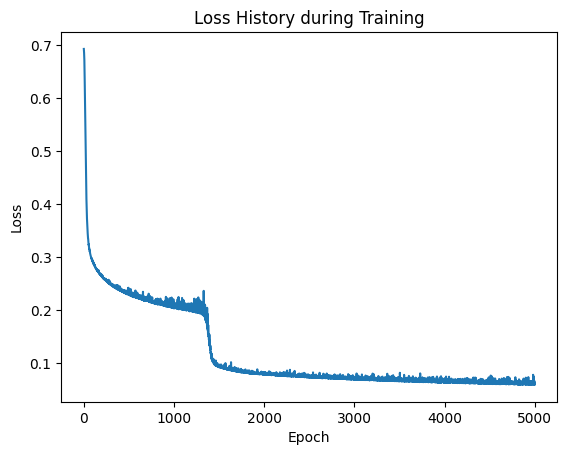

In [ ]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History during Training')
plt.show()

### Accuracy

Final accuracy on the training set — should be well above 50% (the logistic regression baseline):

In [ ]:
y_pred = (mlp.forward(X) > 0.5).astype(int)
accuracy = np.mean(y_pred == y)
print("Accuracy:", accuracy)

Accuracy: 0.981


### Decision Boundary

Unlike logistic regression's linear boundary, the MLP carves a **non-linear** region corresponding to the four quadrants of the XOR pattern:

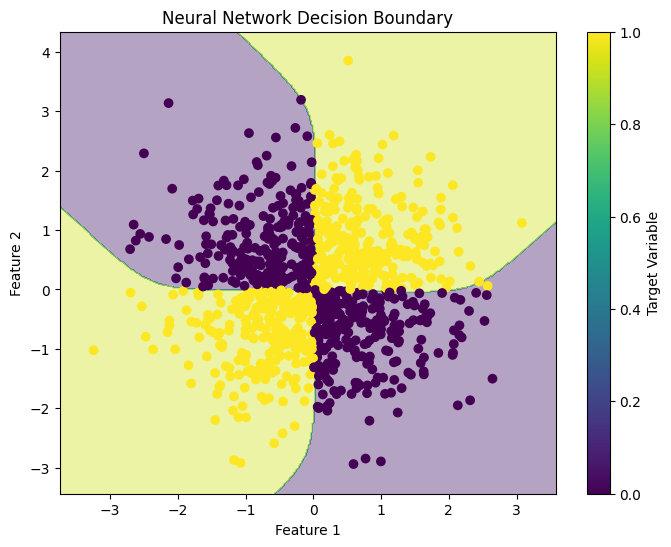

In [ ]:
# Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid
Z = (mlp.forward(np.c_[xx.ravel(), yy.ravel()]) > 0.5).astype(int)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Neural Network Decision Boundary')
plt.colorbar(label='Target Variable')
plt.show()

## Reflection Questions

1. **XOR and linear separability.** Prove that the XOR dataset is not linearly separable. What is the *minimum* number of hidden units needed to solve it exactly?

2. **Weight initialisation.** What happens if you initialise all weights and biases to zero? Why does random initialisation break this symmetry?

3. **Vanishing gradients.** The sigmoid derivative $\sigma'(z) \le 0.25$ always. Show how this causes gradients to shrink exponentially as they propagate through $L$ sigmoid layers. What activation function was introduced to address this?

4. **Mini-batch vs full-batch gradient descent.** What are the advantages of mini-batch gradient descent? What is the effect of making batch size very small (1 = SGD) vs very large (= full batch)?

## Answers

**1. XOR and linear separability.**
The four points $(+,+), (+,-), (-,+), (-,-)$ with labels $1,0,0,1$ cannot be separated by any hyperplane $\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$ — as can be verified by checking that no such $\theta$ satisfies all four constraints simultaneously. The minimum hidden layer size is **2 neurons** (each neuron can fire for one of the two positive quadrants).

**2. Weight initialisation.**
If all weights are zero, then $Z_1 = X \cdot 0 + 0 = 0$, so $A_1 = \sigma(0) = 0.5$ identically for all neurons. The gradients $\frac{\partial \mathcal{L}}{\partial W_1}$ are identical for every neuron, so all weights receive the same update every step — the network has **no capacity** to learn different features. Random initialisation breaks this symmetry.

**3. Vanishing gradients.**
The gradient flowing back through $L$ sigmoid layers is multiplied by $\sigma'(z_l)$ at each layer. Since $\sigma'(z) \le 0.25$, after $L$ layers the gradient is at most $(0.25)^L$, which decays exponentially. **ReLU** ($\max(0,z)$, derivative = 1 for $z > 0$) was introduced to avoid this — gradients pass through unchanged for active neurons.

**4. Mini-batch gradient descent.**
- Full batch: exact gradient, but requires loading all data; slow per epoch on large datasets; smooth loss curve
- Mini-batch: noisy gradient estimate, but faster iterations; the noise can help escape sharp minima; memory-efficient
- SGD (batch=1): maximum noise; can be useful but slow to converge; not vectorised